<a href="https://colab.research.google.com/github/lauragragera/Procesos-Estocasticos/blob/main/GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Muestra con matriz de covarianzas la identidad

In [23]:
vector_medias = np.zeros(3) # Es 0 para las 3 dimensiones
matriz_covarianzas = np.eye(3) # Es la matriz identidad de orden 3
num_samples = 50
samples = np.random.multivariate_normal(
    vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 0.26742468 -0.3750841  -0.36010007]
 [ 2.48479315  0.30459429 -0.02720157]
 [-1.04418265 -0.44728755  0.937186  ]
 [ 1.14732107  0.88602433  2.00654115]
 [-1.41162503  1.14736482  0.52809576]
 [-0.95961143  1.11638208  1.31493611]
 [-0.05060457  0.38752153 -0.70352571]
 [-1.03125502  1.85430089  0.73640428]
 [ 0.68051219  0.46781886 -0.00338123]
 [ 0.43369452  0.48936823 -3.15582538]
 [-0.92188676  0.82723179  0.13708984]
 [ 1.09789107 -1.14009525 -0.13323598]
 [ 0.77627909 -1.22672546  0.46250413]
 [ 1.22838264 -1.29975253 -1.07447748]
 [-0.13859914 -0.28834685  0.25858721]
 [-2.03815451 -0.77348899 -0.4518346 ]
 [ 0.7140022   0.67021862  1.83781496]
 [-0.55756185  0.88268433 -1.83794823]
 [ 1.30168398 -0.06725412 -2.13364139]
 [ 1.10806666 -1.29170869  1.3941518 ]
 [-0.21395138 -0.57510613 -0.79727603]
 [-1.57474493  0.89930855  0.41938888]
 [ 0.6585935   0.24605637 -0.56421173]
 [-1.00553016 -0.54132166  1.15195872]
 [-0.77979765 -0.5800618  -1.14559368

Muestra con matriz de covarianzas $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

In [24]:
vector_medias = np.zeros(3) # Es 0 para las 3 dimensiones
matriz_covarianzas = np.diag([1, 10, 100]) # Es la matriz pedida
num_samples = 50
samples = np.random.multivariate_normal(
    vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 1.25707470e+00 -2.68449471e+00 -3.58236252e+00]
 [-5.50089626e-01  3.50495509e+00 -6.81307420e-01]
 [ 1.91540124e+00 -4.56836117e+00 -8.72853231e+00]
 [-7.63142421e-01  3.54707397e+00 -7.33194716e+00]
 [-5.19369047e-01 -2.54727289e+00  8.94878429e+00]
 [-2.17560887e+00 -2.97526370e+00  6.66229696e+00]
 [-1.25580812e+00  2.13303441e+00 -7.66982571e+00]
 [-3.64220789e-01 -7.13101191e-03  8.03591687e+00]
 [ 7.12822835e-01  3.36993272e+00 -7.12689853e+00]
 [-1.08109613e+00  1.82038486e+00 -2.98853745e+01]
 [-6.14487921e-01 -1.08206416e-01  7.80673429e+00]
 [-1.90267229e+00  6.16475585e-01 -1.30226928e+01]
 [-4.38163844e-01  2.99295743e+00 -5.61505534e+00]
 [-4.54469629e-01  8.45668350e-01 -1.00145726e+01]
 [ 1.09159681e+00 -6.73246453e-01  1.08702367e+01]
 [ 2.92225543e-01 -4.90899350e-01 -1.54248012e+01]
 [-4.38712976e-01 -5.64957059e+00 -1.37767336e+01]
 [ 1.97869890e+00  7.44639675e-01 -2.95408010e+00]
 [ 4.73936160e-01  2.27287685e+00 -1.54256981e+00]
 [-3

Diferencias:
- Los vectores de medias son iguales, así que todos los valores de ambas muestras están centrados en 0.
- Los valores de una columna siguen sin depender de los de las otras (no hay patrones cruzados), ya que la covarianza entre dimensiones sigue siendo 0.
- La diferencia fundamental está en la amplitud de los números generados (la varianza):
    - En la primera columna (varianza 1), los valores se mantienen muy concentrados cerca del 0 (casi todos entre -3 y 3).
    - En la segunda columna (varianza 10), los valores tienen una dispersión moderada, alcanzando números más altos (típicamente entre -10 y 10).
    - En la tercera columna (varianza 100), la dispersión se dispara, generando números mucho más grandes en valor absoluto (llegando a rondar entre -30 y 30).

## 2. Simular un GP con kernel RBF

In [25]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: vector de medias.
  vector_medias = np.zeros_like(t)

  # Paso 2: matriz de covarianzas.
  matriz_de_diferencias = t[:, None] - t[None, :] #Shape: (n,n)
  matriz_covs = sigma_sq * np.exp(-0.5 * (matriz_de_diferencias / lengthscale)**2) # Shape: (n,n)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

### RECREACIÓN DIAPOSITIVA 59: Efecto de Sigma (Amplitud) con lengthscale=1

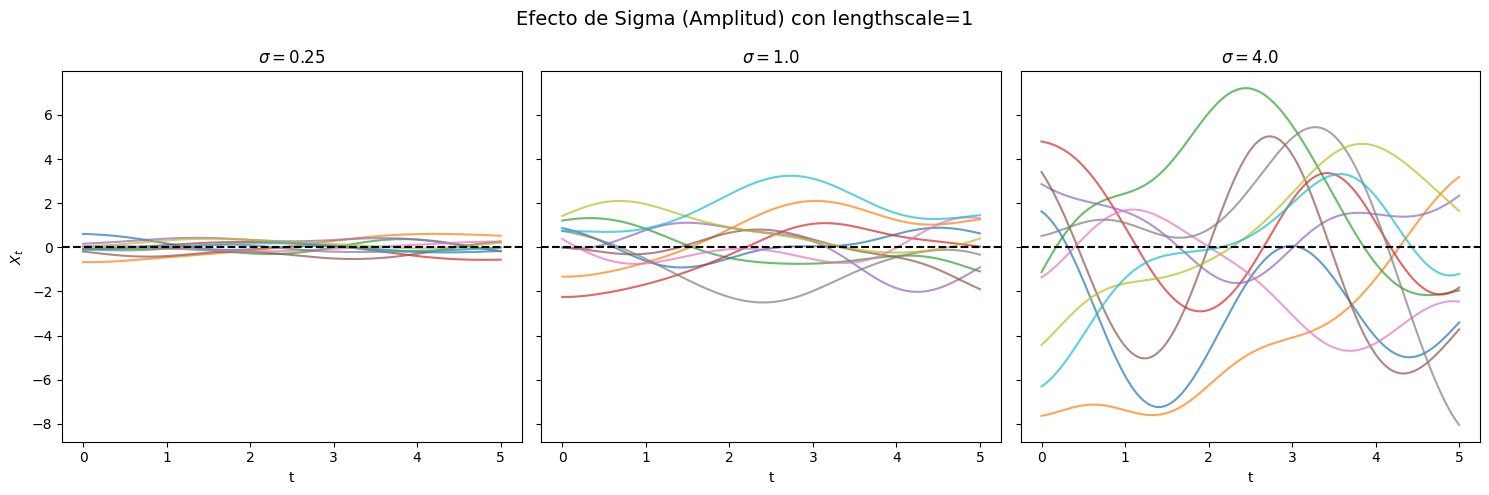

In [26]:
# 1. Definimos el grid de localizaciones t (500 puntos en el intervalo [0, 5])
t = np.linspace(0, 5, 500)

# 2. Definimos cuántas trayectorias queremos pintar por gráfica
num_muestras = 10

sigmas = [0.25, 1.0, 4.0]
lengthscale_fijo = 1.0

# Creamos la figura con 3 subplots alineados horizontalmente.
fig1, axs1 = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig1.suptitle('Efecto de Sigma (Amplitud) con lengthscale=1', fontsize=14)

for i, sigma in enumerate(sigmas):
    # La función pide sigma_sq (varianza), así que elevamos sigma al cuadrado
    muestras = simular_GP_RBF(t, sigma_sq=sigma**2, lengthscale=lengthscale_fijo, num_samples=num_muestras)

    # Pintamos cada una de las 10 trayectorias
    for j in range(num_muestras):
        axs1[i].plot(t, muestras[j, :], alpha=0.7) # alpha da transparencia

    # Detalles estéticos (títulos, ejes, línea base en 0)
    axs1[i].set_title(f'$\\sigma = {sigma}$') #titulo
    axs1[i].set_xlabel('t') #Eje X
    axs1[i].axhline(0, color='black', linestyle='--') # Línea de la media (0)

    if i == 0:
        axs1[i].set_ylabel('$X_t$') #Eje Y (solo en el primer gráfico)

plt.tight_layout()
plt.show()


### RECREACIÓN DIAPOSITIVA 62: Efecto del Lengthscale con sigma=1

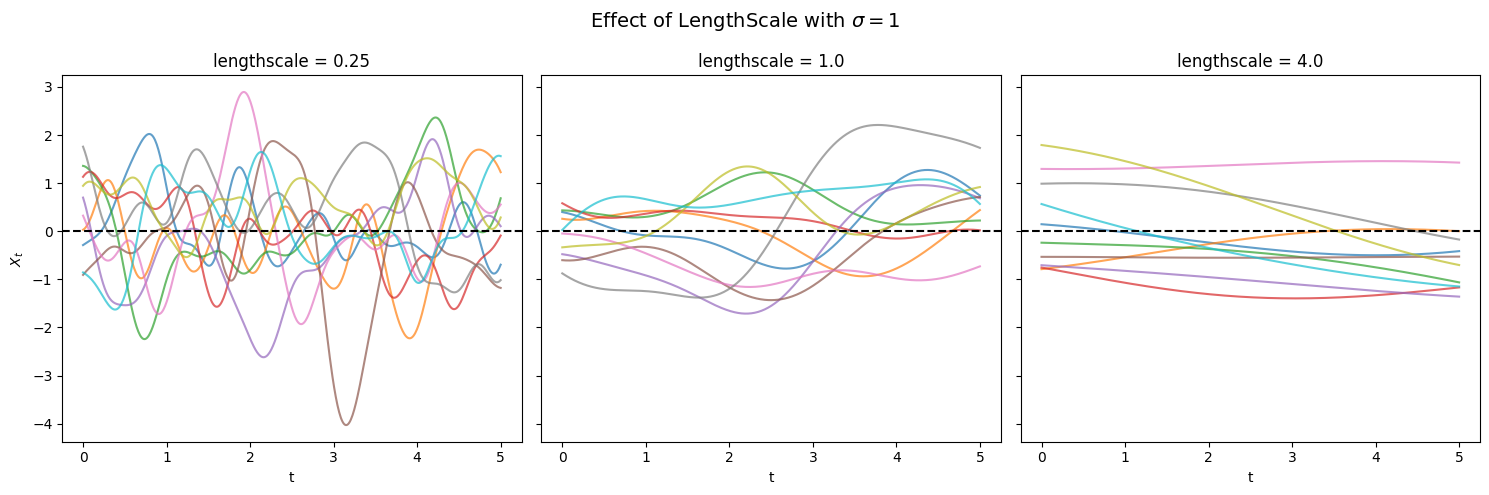

In [27]:
sigma_fijo = 1.0
lengthscales = [0.25, 1.0, 4.0]

fig2, axs2 = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig2.suptitle('Effect of LengthScale with $\\sigma=1$', fontsize=14)

for i, l in enumerate(lengthscales):
    # Generamos las muestras
    muestras = simular_GP_RBF(t, sigma_sq=sigma_fijo**2, lengthscale=l, num_samples=num_muestras)

    # Pintamos las trayectorias
    for j in range(num_muestras):
        axs2[i].plot(t, muestras[j, :], alpha=0.7)

    # Detalles estéticos
    axs2[i].set_title(f'lengthscale = {l}')
    axs2[i].set_xlabel('t')
    axs2[i].axhline(0, color='black', linestyle='--')

    if i == 0:
        axs2[i].set_ylabel('$X_t$')

plt.tight_layout()
plt.show()

## 3.Simular un GP con kernel periódico

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def simular_GP_periodic(t, sigma_sq=1.0, lengthscale=1.0, p=1.0, num_samples=1):
    """
    Simular un GP con kernel Periódico.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza (amplitud) del kernel. Float.
    lengthscale: parámetro de escala de longitud del kernel. Float.
    p: periodo del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    # Paso 1: Vector de medias (constantemente cero)
    vector_medias = np.zeros_like(t)

    # Paso 2: Matriz de distancias d = |t_i - t_j| usando broadcasting
    matriz_de_distancias = np.abs(t[:, None] - t[None, :])

    # Calculamos la matriz de covarianzas aplicando la fórmula del kernel periódico
    matriz_covs = sigma_sq * np.exp(-(2.0 / lengthscale**2) * np.sin(np.pi * matriz_de_distancias / p)**2)

    # Paso 3: Obtenemos las muestras de la normal multivariante
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

### RECREACIÓN DIAPOSITIVA 72

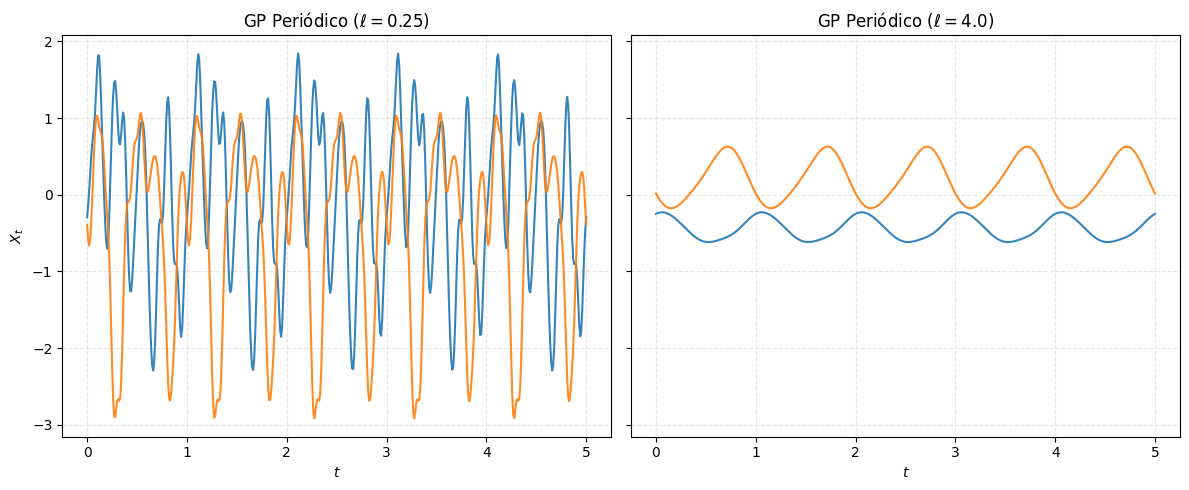

In [29]:
t = np.linspace(0, 5, 500)
num_muestras = 2

sigma_sq = 1.0
p = 1.0 #
lengthscales = [0.25, 4.0]

# Creamos figura con 2 subplots alineados (comparten eje Y)
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, l in enumerate(lengthscales):
    # Generamos las muestras con la función del kernel periódico
    muestras = simular_GP_periodic(t, sigma_sq=sigma_sq, lengthscale=l, p=p, num_samples=num_muestras)

    # Pintamos las 2 trayectorias
    for j in range(num_muestras):
        axs[i].plot(t, muestras[j, :], alpha=0.9)

    axs[i].set_title(rf'GP Periódico ($\ell = {l}$)') # Titulo
    axs[i].set_xlabel('$t$') # Eje X
    axs[i].grid(True, alpha=0.3, linestyle='--') # Cuadrícula de fondo

    if i == 0:
        axs[i].set_ylabel('$X_t$') # Eje Y (solo en el primer grafico)

plt.tight_layout() # Ajusta el espaciado
plt.show() # Muestra la figura

### RECREACIÓN DIAPOSITIVA 74

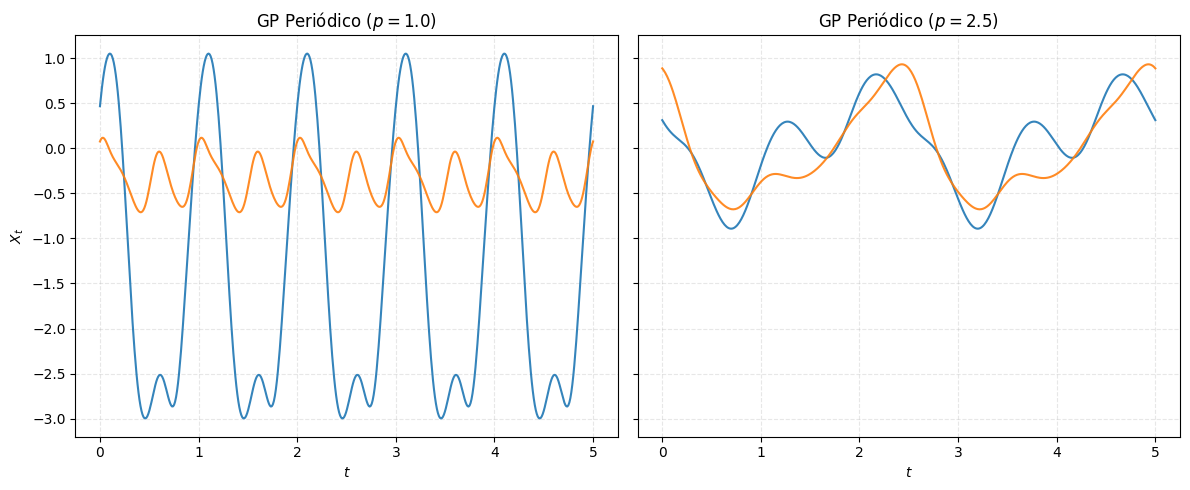

In [30]:
# Definimos el grid de localizaciones t (500 puntos en [0, 5])
t = np.linspace(0, 5, 500)
num_muestras = 2

# Parámetros fijos según la diapositiva
sigma_sq = 1.0
lengthscale_fijo = 1.0
periodos = [1.0, 2.5] # Valores de p a evaluar

# Creamos figura con 2 subplots alineados (comparten eje Y)
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, p_val in enumerate(periodos):
    # Generamos las muestras con la función del kernel periódico
    muestras = simular_GP_periodic(t, sigma_sq=sigma_sq, lengthscale=lengthscale_fijo, p=p_val, num_samples=num_muestras)

    # Pintamos las 2 trayectorias
    for j in range(num_muestras):
        axs[i].plot(t, muestras[j, :], alpha=0.9)

    axs[i].set_title(rf'GP Periódico ($p = {p_val}$)') # Titulo
    axs[i].set_xlabel('$t$') # Eje X
    axs[i].grid(True, alpha=0.3, linestyle='--') # Cuadrícula de fondo

    if i == 0:
        axs[i].set_ylabel('$X_t$') # Eje Y (solo en el primer grafico)

plt.tight_layout() # Ajusta el espaciado
plt.show() # Muestra la figura

### RECREACIÓN DIAPOSITIVA 76

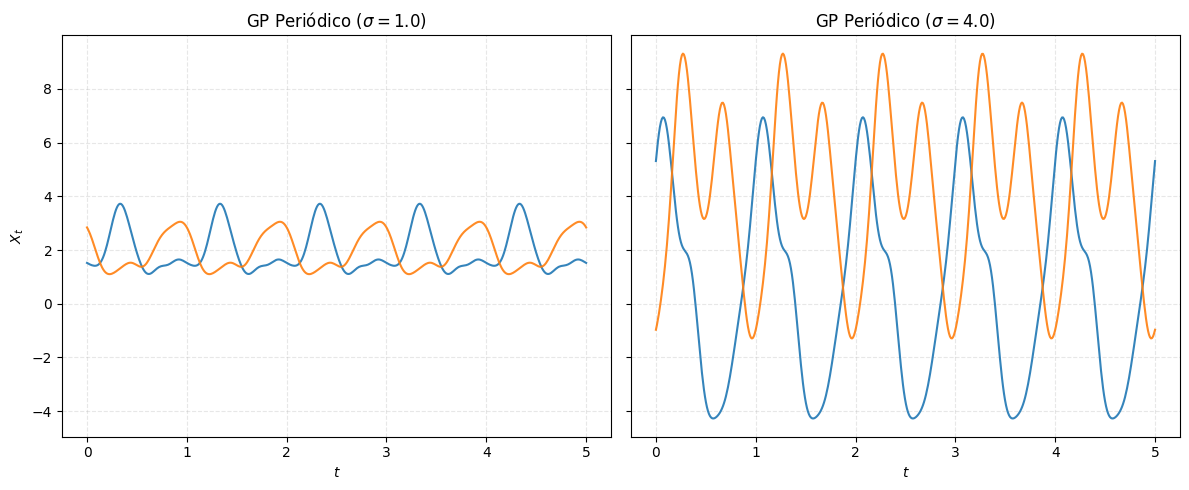

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el grid de localizaciones t (500 puntos en [0, 5])
t = np.linspace(0, 5, 500)
num_muestras = 2

# Parámetros fijos según la diapositiva
p_fijo = 1.0
lengthscale_fijo = 1.0
sigmas = [1.0, 4.0] # Valores de sigma a evaluar

# Creamos figura con 2 subplots alineados (comparten eje Y)
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, sigma in enumerate(sigmas):
    muestras = simular_GP_periodic(t, sigma_sq=sigma**2, lengthscale=lengthscale_fijo, p=p_fijo, num_samples=num_muestras)

    # Pintamos las 2 trayectorias
    for j in range(num_muestras):
        axs[i].plot(t, muestras[j, :], alpha=0.9)

    axs[i].set_title(rf'GP Periódico ($\sigma = {sigma}$)') # Titulo
    axs[i].set_xlabel('$t$') # Eje X
    axs[i].grid(True, alpha=0.3, linestyle='--') # Cuadrícula de fondo

    if i == 0:
        axs[i].set_ylabel('$X_t$') # Eje Y (solo en el primer grafico)

plt.tight_layout() # Ajusta el espaciado
plt.show() # Muestra la figura

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo de los monomios utilizados. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    n = len(t)

    # Paso 1: calcula el vector de medias.
    vector_medias = np.zeros(n)   # Shape: (n,)

    # Paso 2: calcula la matriz de covarianzas
    # [OPCIÓN 2: Usando el producto matricial F*F^T visto en la diapositiva 82]
    F = np.column_stack([t**i for i in range(m + 1)])
    # Creamos la matriz F de tamaño (n, m+1) donde cada columna es t^i
    matriz_covs = F @ F.T # Producto matricial F * F^T

    # Añadimos ruido definido positivo para estabilidad numérica
    matriz_covs = matriz_covs + 1e-9 * np.eye(n)

    # Paso 3: obtén las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(
        vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)

    return samples

In [33]:
### RECREACIÓN DIAPOSITIVA 89

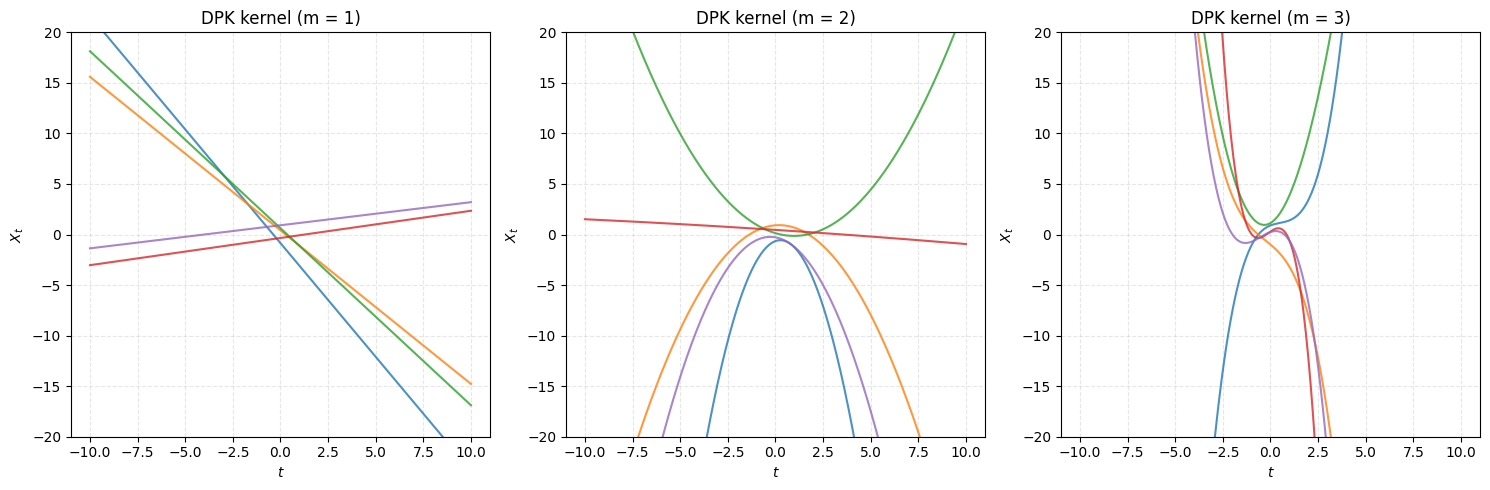

In [34]:
# Definimos el grid de localizaciones t (500 puntos en [-10, 10])
t = np.linspace(-10, 10, 500)
num_muestras = 5

m_values = [1, 2, 3] # Valores de m a evaluar

# Creamos figura con 3 subplots alineados
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, m in enumerate(m_values):
    # Generamos las muestras con la función del kernel DPK
    muestras = simular_GP_DPKpoly(t, m=m, num_samples=num_muestras)

    # Pintamos las 5 trayectorias
    for j in range(num_muestras):
        axs[i].plot(t, muestras[j, :], alpha=0.8)

    axs[i].set_title(f'DPK kernel (m = {m})') # Titulo
    axs[i].set_xlabel('$t$') # Eje X
    axs[i].set_ylabel('$X_t$') # Eje Y
    axs[i].set_ylim(-20, 20) # Fijamos el límite de Y a [-20, 20]
    axs[i].grid(True, alpha=0.3, linestyle='--') # Cuadrícula de fondo

plt.tight_layout() # Ajusta el espaciado
plt.show() # Muestra la figura

## 5. ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

<class '__main__.RBF'>
(100, 100)
<class '__main__.Zero_Mean_Function'>
(100,)
True


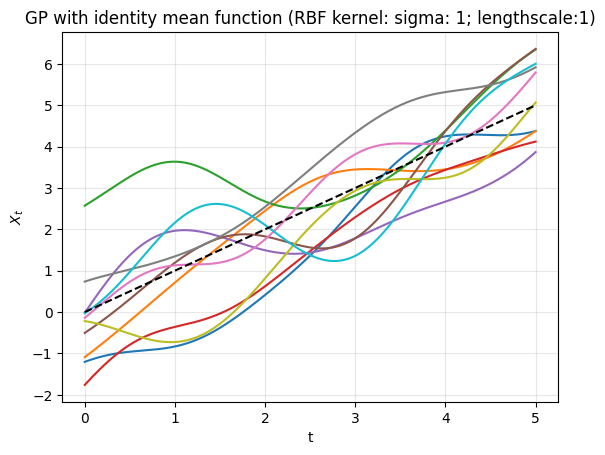

In [35]:
class RBF:
    def __init__(self, sigma_sq=1, lengthscale=1):
        self.sigma_sq = sigma_sq
        self.lengthscale = lengthscale

    def __call__(self, t, s):
        dists = t[:, None] - s[None, :]
        cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
        return cov_matrix

my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel)) # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0, 10, 100)
cov_mat = my_kernel(t, t)  # Aquí estamos usando el método __call__
print(cov_mat.shape) # Aquí deberíamos obtener una matriz con shape (100, 100)

class Zero_Mean_Function:
    def __init__(self):
        pass

    def __call__(self, t):
        return np.zeros_like(t)

my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean == 0).all())

def simular_GP(t, mf, kernel, num_samples=1):
    vector_medias = mf(t)
    matriz_covs = kernel(t, t)
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
    return samples

class Identity_Mean_Function:
    def __init__(self):
        pass

    def __call__(self, t):
        return t

my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0, 5, 500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
    plt.plot(t, samples[i, :])

plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()